In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [58]:
print(os.getcwd())
filepath = os.path.join(os.path.dirname(os.getcwd()), 'data/dataset/processed/go_emotion_dutch.csv')

c:\Users\koenm\Documents\repositorys\year_2\fae2-nlpr-group-group-4-1\fae2-nlpr-group-group-4-1\nlp_cia\task 6


In [59]:
df_train = pd.read_csv(filepath)
df_train = df_train.sample(n=len(df_train))

In [60]:
df_train.head()

,Sentence,Emotion,Emotion_encoded
15770,Ik gebruik Firefox met mijn 5 extensies en één...,happiness,0
45055,Ik denk nog steeds graag dat de combinatie van...,neutral,6
33711,Veel geluk! Ook je verhaal heeft me aan het de...,happiness,0
5735,Ik wist niet dat ik mijn ogen zo ver in mijn h...,happiness,0
52506,kunnen we een powerstone-remake krijgen? hoe z...,neutral,6


In [61]:
filepath_2 = os.path.join(os.path.dirname(os.getcwd()), "data/group_4_url_1_transcript.csv")
df_test = pd.read_csv(filepath_2)
df_test = df_test.sample(n=len(df_test))

In [62]:
df_test.head()

,Start Time,End Time,Sentence,Translation,Emotion_fine,Emotion_core,Intensity
621,1900-01-01 00:31:27.480000,1900-01-01 00:31:29.480000,Maar een kist met een slot erop.,But a chest with a lock on it.,curiosity,neutral,mild
769,1900-01-01 00:39:50.640000,1900-01-01 00:39:53.640000,volgens in de Nederlandse taal of juist andersom.,according to in the Dutch language or the othe...,confusion,neutral,mild
451,1900-01-01 00:23:33.379000,1900-01-01 00:23:36.379000,"En als we die mee zouden nemen, daar moesten w...","And if we were to take those with us, we had t...",caution,fear,mild
783,1900-01-01 00:40:28.640000,1900-01-01 00:40:30.640000,"God, ik had hem weer zo.","God, I had him like that again.",frustration,anger,moderate
396,1900-01-01 00:20:38.379000,1900-01-01 00:20:41.360000,Maar aan de andere kant zit je blind te staan.,"But on the other hand, you're standing there b...",confusion,sadness,moderate


In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train on df_train
vectorizer = TfidfVectorizer(
    max_features=7000,        # Keep top N most frequent words
    ngram_range=(1, 2),       # (1,1) = unigrams, (1,2) = uni+bigrams
    min_df=2,                 # Ignore words appearing in < 2 documents
    max_df=0.95,              # Ignore words appearing in > 95% of docs
    sublinear_tf=True,        # Apply log scaling to term frequency
    use_idf=True,             # Use inverse document frequency
    norm='l2'                 # Normalize vectors to unit length
)
X_train_tfidf = vectorizer.fit_transform(df_train['Sentence'])

model = MultinomialNB(alpha=1.0,                # Smoothing parameter (higher = more smoothing)
                      fit_prior=True ).fit(X_train_tfidf, df_train['Emotion'])


# Test on df_test
X_test_tfidf = vectorizer.transform(df_test['Sentence'])
predictions = model.predict(X_test_tfidf)

# Calculate metrics
accuracy = accuracy_score(df_test['Emotion_core'], predictions)
precision = precision_score(df_test['Emotion_core'], predictions, average='weighted')
recall = recall_score(df_test['Emotion_core'], predictions, average='weighted')
f1 = f1_score(df_test['Emotion_core'], predictions, average='weighted')

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

Accuracy:  0.384
Precision: 0.500
Recall:    0.384
F1-score:  0.348


c:\Users\koenm\miniconda3\envs\p12dupa\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [90]:
# Try different alpha values
for alpha in [0.1, 0.5, 1.0, 2.0]:
    model = MultinomialNB(alpha=alpha).fit(X_train_tfidf, df_train['Emotion'])
    predictions = model.predict(X_test_tfidf)
    acc = accuracy_score(df_test['Emotion_core'], predictions)
    print(f"Alpha={alpha}: {acc:.3f}")

Alpha=0.1: 0.393
Alpha=0.5: 0.394
Alpha=1.0: 0.384
Alpha=2.0: 0.358


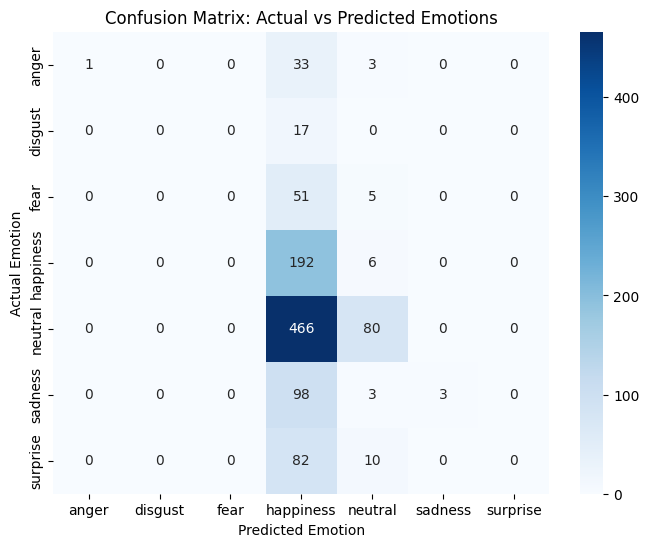


Prediction Distribution:
happiness    939
neutral      107
sadness        3
anger          1
Name: count, dtype: int64

Actual Distribution:
Emotion_core
neutral      546
happiness    198
sadness      104
surprise      92
fear          56
anger         37
disgust       17
Name: count, dtype: int64


In [88]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train on df_train
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(df_train['Sentence'])
model = MultinomialNB().fit(X_train_tfidf, df_train['Emotion'])

# Test on df_test
X_test_tfidf = vectorizer.transform(df_test['Sentence'])
predictions = model.predict(X_test_tfidf)

# Create confusion matrix
cm = confusion_matrix(df_test['Emotion_core'], predictions)
emotions = sorted(df_test['Emotion_core'].unique())

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotions, yticklabels=emotions)
plt.title('Confusion Matrix: Actual vs Predicted Emotions')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

# Show prediction distribution
print("\nPrediction Distribution:")
print(pd.Series(predictions).value_counts())
print("\nActual Distribution:")
print(df_test['Emotion_core'].value_counts())